# ทดลองทำกราฟ — Student Social Media & Mental Health

เปิดจากโฟลเดอร์ `coding/`:

```fish
uv run jupyter lab
```

โน้ตบุ๊กนี้ใช้ของจาก `src/proposal_viz/` ได้ตรง ๆ (uv ลง package แบบ editable ให้แล้ว)
แก้ `plots.py` แล้วรันเซลล์ใหม่ได้เลย ไม่ต้อง restart kernel — เปิด `autoreload` ไว้ให้แล้ว

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from proposal_viz import data, plots, style

# backend=None = ไม่ยุ่งกับ backend ของ notebook รูปจะได้โผล่ใต้เซลล์
style.apply_style(backend=None)

dataset = data.load()
df = dataset.df
note = dataset.source_note
print(note)
df.head()

ข้อมูลจำลอง (synthetic) สร้างเพื่อทดสอบรูปแบบกราฟเท่านั้น — ยังไม่ใช่ผลวิเคราะห์จริง


,student_id,year,main_platform,usage_hours,sleep_hours,physical_activity,stress_score,depression_score,gpa
0,1,ปี 4,Instagram,3.85,7.97,2.81,3.24,4.15,3.23
1,2,ปี 1,Instagram,3.32,7.30,2.32,2.14,3.50,3.62
2,3,ปี 1,X (Twitter),3.01,9.03,1.71,2.89,4.96,3.45
3,4,ปี 3,Facebook,3.97,8.60,5.06,2.53,3.08,3.38
4,5,ปี 4,Facebook,2.94,6.19,3.42,3.99,7.31,3.47


## 1. ดูข้อมูลก่อนวาด

ก่อนวาดกราฟ ควรรู้ก่อนว่ามีกี่แถว คอลัมน์ชนิดอะไร ค่าหายไหม ค่าสุดโต่งแปลก ๆ มีหรือเปล่า
ไม่งั้นกราฟจะสวยแต่เล่าเรื่องผิด

In [2]:
df.info()
print("\nค่าว่างต่อคอลัมน์:")
print(df.isna().sum())

df.describe().round(2)

<class 'pandas.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   student_id         480 non-null    int64  
 1   year               480 non-null    str    
 2   main_platform      480 non-null    str    
 3   usage_hours        480 non-null    float64
 4   sleep_hours        480 non-null    float64
 5   physical_activity  480 non-null    float64
 6   stress_score       480 non-null    float64
 7   depression_score   480 non-null    float64
 8   gpa                480 non-null    float64
dtypes: float64(6), int64(1), str(2)
memory usage: 33.9 KB

ค่าว่างต่อคอลัมน์:
student_id           0
year                 0
main_platform        0
usage_hours          0
sleep_hours          0
physical_activity    0
stress_score         0
depression_score     0
gpa                  0
dtype: int64


,student_id,usage_hours,sleep_hours,physical_activity,stress_score,depression_score,gpa
count,480.00,480.00,480.00,480.00,480.00,480.00,480.00
mean,240.50,3.93,7.33,3.75,3.96,4.49,3.45
std,138.71,1.96,1.00,1.78,1.51,1.72,0.32
min,1.00,0.51,3.96,0.00,1.00,1.00,2.65
25%,120.75,2.52,6.69,2.42,2.88,3.26,3.23
50%,240.50,3.64,7.37,3.80,3.92,4.46,3.46
75%,360.25,4.94,8.00,4.93,4.98,5.72,3.67
max,480.00,11.68,10.30,9.34,10.00,10.00,4.00


## 2. วาดเร็ว ๆ ในโน้ตบุ๊ก

ข้อดีของ notebook คือลองแล้วเห็นผลทันที ลองแก้ `bins` เป็น 5 / 14 / 40 แล้วรันซ้ำ
จะเห็นว่าจำนวน bin เปลี่ยน "เรื่อง" ที่กราฟเล่าได้เลย

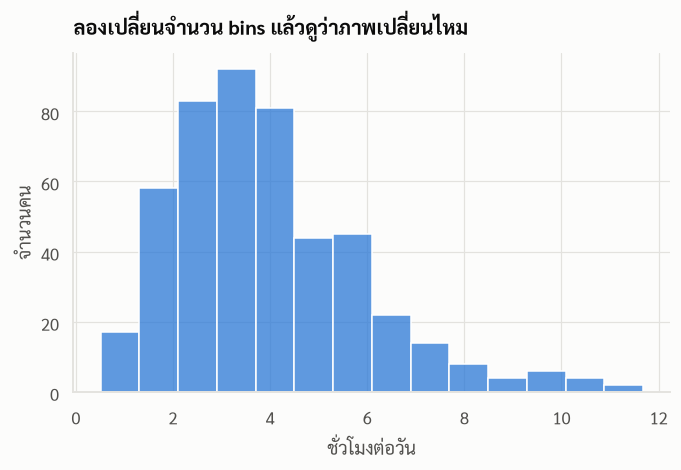

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.histplot(df, x="usage_hours", bins=14, color=style.SERIES[0], edgecolor="white", ax=ax)

ax.set_title("ลองเปลี่ยนจำนวน bins แล้วดูว่าภาพเปลี่ยนไหม")
ax.set_xlabel("ชั่วโมงต่อวัน")
ax.set_ylabel("จำนวนคน")
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.show()

## 3. เรียกกราฟที่ทำไว้แล้ว

ทุกฟังก์ชันใน `plots.py` คืน `Figure` เลยเอามาโชว์ในโน้ตบุ๊กได้ตรง ๆ
ดูรายชื่อทั้งหมดได้จาก `plots.ALL`

In [ ]:
print(list(plots.ALL))

plots.usage_vs_depression(df, note)

## 4. ที่ว่างสำหรับลองเอง

คำถามที่กราฟน่าจะตอบได้ ลองเลือกสักข้อแล้ววาดดู:

1. คนที่นอนน้อยกว่า 6 ชม. กับคนที่นอนมากกว่า 8 ชม. คะแนนเครียดต่างกันแค่ไหน (`boxplot` หรือแท่งค่าเฉลี่ย)
2. เกรดเฉลี่ยลดลงจริงไหมเมื่อใช้โซเชียลนานขึ้น — และถ้าคุมตัวแปร "ชั่วโมงการนอน" ด้วยล่ะ
3. นักศึกษาแต่ละชั้นปี (`year`) ใช้เวลาต่างกันไหม
4. กิจกรรมทางกายช่วยลดคะแนนซึมเศร้าได้หรือเปล่า

ท่าที่ใช้บ่อย:

```python
df.groupby("year")["usage_hours"].mean()          # ค่าเฉลี่ยรายกลุ่ม
pd.cut(df["sleep_hours"], [0, 6, 8, 24])          # แบ่งช่วงตัวเลขเป็นกลุ่ม
sns.boxplot(df, x="year", y="stress_score")       # เทียบการกระจายระหว่างกลุ่ม
sns.barplot(df, x="year", y="gpa", errorbar="ci") # ค่าเฉลี่ย + ช่วงความเชื่อมั่น
```

**เตือนไว้ก่อน:** ตอนนี้ยังเป็นข้อมูลจำลอง ความสัมพันธ์ที่เห็นเป็นของที่ใส่ไว้เองใน `data.py`
ห้ามเอาตัวเลขไปสรุปในเล่ม รอไฟล์จริงจาก Kaggle ก่อน

In [ ]:
# ตัวช่วยเริ่มต้นข้อ 1 — แบ่งกลุ่มการนอน แล้วดูคะแนนเครียดเฉลี่ย
sleep_group = pd.cut(df["sleep_hours"], [0, 6, 8, 24], labels=["< 6 ชม.", "6–8 ชม.", "> 8 ชม."])
df.groupby(sleep_group, observed=False)["stress_score"].agg(["mean", "count"]).round(2)

# ต่อเอง: เอาผลข้างบนมาวาดเป็นกราฟ

## 5. ได้กราฟที่ชอบแล้ว ทำยังไงต่อ

โน้ตบุ๊กเหมาะกับการ **ลอง** แต่ไม่เหมาะกับการเก็บของที่จะใช้จริง (รันสลับลำดับเซลล์แล้วผลเพี้ยนได้)
พอได้กราฟที่จะใส่ในเล่มแล้ว ให้ย้ายโค้ดไปเป็นฟังก์ชันใน `plots.py` แล้วเพิ่มชื่อลงใน `plots.ALL`
จากนั้น `uv run proposal-viz` จะสร้างรูปนั้นให้ทุกครั้งเหมือนเดิมเป๊ะ ๆ

ระหว่างนี้จะเซฟจากโน้ตบุ๊กก่อนก็ได้:

In [ ]:
fig = plots.correlation_heatmap(df, note)
fig.savefig("../output/test-from-notebook.png", dpi=200, bbox_inches="tight")